### **Project : Demand Forecasting System**
### **Algorithm : Random Forest Regressor**

In [1]:
# Step No 1 : Import Required Libraries 

# Import Numerical Library
import numpy as np 

# Import Data Manipulation Library
import pandas as pd

# Import Plotting Library 
import matplotlib.pyplot as plt 

# Import Advanced Plotting Library
import seaborn as sns

# Import Train Test Split 
from sklearn.model_selection import train_test_split

# Import Random Forest Regressor 
from sklearn.ensemble import RandomForestRegressor

# Import Evaluation Metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [2]:
# Step No 2 : Load dataset 
df = pd.read_csv("Demand_Forecasting_Dataset.csv")

In [3]:
# Step No 3 : Data Understanding

# Display first rows 
print(df.head())

# Display shape 
print(df.shape)

# Display Information
print(df.info())

# Display Statistical Summary 
print(df.describe())

         Date  ProductID  StoreID  UnitsSold    Price  Discount  \
0  2023-01-01       1051       15        122  1490.79        20   
1  2023-01-02       1021        2        113  1471.80        29   
2  2023-01-03       1020        1        133   678.06        21   
3  2023-01-04       1041       16        309   542.27        46   
4  2023-01-05       1054        3        175  1733.89         6   

   MarketingSpend  Holiday  DayOfWeek  Month  Demand  
0            7265        0          6      1  122.30  
1            3433        0          0      1  113.40  
2            7396        0          1      1  133.58  
3           36773        0          2      1  309.78  
4           31740        0          3      1  175.76  
(1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1000 non-null   object 
 1   ProductID 

In [4]:
# Step No 4 : Data Cleaning 
# Check missing values
print(df.isnull().sum())

# Check duplicate rows 
print(df.duplicated().sum())

# Remove duplicate rows 
df = df.drop_duplicates()

Date              0
ProductID         0
StoreID           0
UnitsSold         0
Price             0
Discount          0
MarketingSpend    0
Holiday           0
DayOfWeek         0
Month             0
Demand            0
dtype: int64
0


In [5]:
# Step No 5 : Convert Date Column

# Convert Date into datetime 
df["Date"] = pd.to_datetime(df["Date"])

# Extract Year 
df["Year"] = df["Date"].dt.year

# Extract Day 
df["Day"] = df["Date"].dt.day



In [6]:
# Step No 6 : Feature and Target Split 

# Define input features 
X = df[[
    "ProductID",
    "StoreID",
    "UnitsSold",
    "Price",
    "Discount",
    "MarketingSpend",
    "Holiday",
    "DayOfWeek",
    "Month",
    "Year",
    "Day"
]]

# Define target variable 
y = df["Demand"]

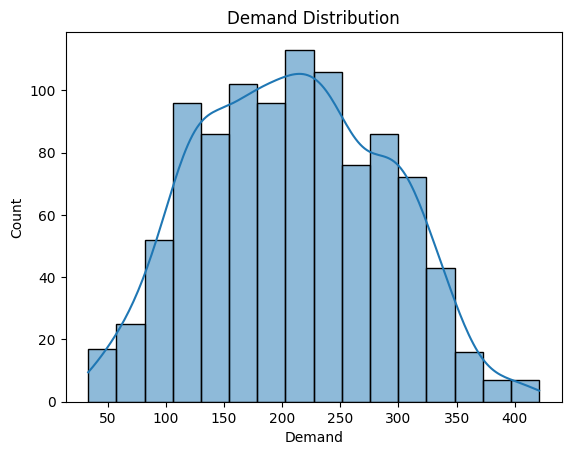

In [7]:
# Step No 7 : Visualization

# Plot Demand Distribution
sns.histplot(
    df["Demand"],
    kde=True
)

# Set title 
plt.title("Demand Distribution")

# Display Plot 
plt.show()

In [8]:
# Step No 8 : Train Test Split 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Step No 9 : Initialize Model 
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [10]:
# Step No 10 : Train Model 
model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [11]:
# Step No 11 : Prediction

y_pred = model.predict(X_test)

# Display the Predicted value 
print("Predicted Demand Values : ")

print(y_pred)

Predicted Demand Values : 
[221.9766 177.5044 115.7296 313.9608 320.4615 100.3901 205.5645 186.3106
 192.491  295.9437 108.0713 303.7813 212.2524 221.1651  66.2899 150.3181
 177.3828 231.3902 173.7892 304.4065 112.4316 150.762  180.0288 236.2286
 313.1011 282.9657 218.7007 167.4782 207.2257  86.2156  54.3255 115.535
 182.459  199.0759 238.252  306.4404 244.5585 268.9751 226.5082 335.3883
 283.3767 216.6051 182.6257 146.1798 199.2112 216.4783 152.9958 224.296
 167.1488 160.6379 115.9509 290.2712 137.5186 268.9888 146.8601 391.1546
  64.4376 353.1603 317.6108 233.1827 219.4771 219.7633  87.6508 115.5578
 338.1283 289.3362 208.8086 306.3451 167.5952 304.3239 185.0311 237.5714
  94.3807 180.0811 245.3162 122.6386 202.6756 337.6477 146.13    74.9032
 144.3435 185.6096  43.8005 234.4084 177.571  163.7072  93.9184 238.1656
 156.6408 193.0478 202.6553 353.1027 241.4141 304.015  257.2813 295.6902
 325.8053 293.1987 236.2512 287.167  111.0926 193.6269 110.918  198.5018
 281.6531 226.3631 179.434

In [12]:
# Step No 12 : Evaluation Metrics 

# Evalute MAE (Mean Absolute Error )
print("Mean Absolute Error : ")
print(
    mean_absolute_error(y_test , y_pred)
)

# Evaluate MSE (Mean Squared Error)
print("Mean Squared Error : ")
print(mean_squared_error(y_test , y_pred))

# Evaluate R2 Score 
print("r2 Score : ")
print(r2_score(y_test , y_pred))

# Evaluate Root Mean Squared Error (RMSE)
print("Root Mean Squared Error : ")
print(np.sqrt(mean_squared_error(y_test , y_pred)))

Mean Absolute Error : 
0.46833599999998243
Mean Squared Error : 
0.45628045779999354
r2 Score : 
0.9999233409577825
Root Mean Squared Error : 
0.6754853498041195


In [13]:
# Step No 13 : Feature Importance 

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by = "Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
2        UnitsSold    0.999761
10             Day    0.000056
1          StoreID    0.000034
5   MarketingSpend    0.000024
3            Price    0.000023
8            Month    0.000023
0        ProductID    0.000023
4         Discount    0.000022
7        DayOfWeek    0.000020
9             Year    0.000012
6          Holiday    0.000001


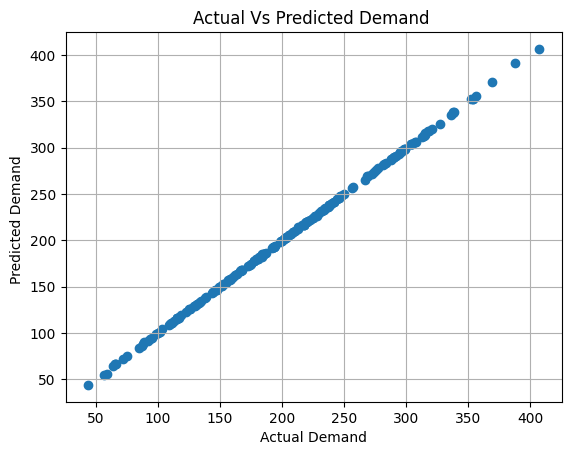

In [14]:
# Step No 14 : Actual Vs Predicted Plot 
# Create Scatter Plot 
plt.scatter(y_test , y_pred)

# Set the Plot title 
plt.title("Actual Vs Predicted Demand ")

# Set X-axis label 
plt.xlabel("Actual Demand")

# Set Y-axis label 
plt.ylabel("Predicted Demand ")

# Set Grid 
plt.grid()

# Display the output 
plt.show()

In [15]:
# Step No 15 : User Input 

product_id = int(input("Enter Product ID : "))

store_id = int(input("Enter Store ID : "))

units_sold = int(input("Enter Units Sold : "))

price = float(input("Enter Product Price : "))

discount = int(input("Enter Discount : "))

marketing_spend = int(input("Enter Marketing Spend : "))

holiday = int(input("Enter Holiday (0/1)"))

day_of_week = int(input("Enter Day of Week (0-6) : "))

month = int(input("Enter Month : "))

year = int(input("Enter Year : "))

day = int(input("Enter day : "))




In [16]:
# Step No : 16 : Create User DataFrame 
user_data = pd.DataFrame({
    "ProductID":[product_id],
    "StoreID":[store_id],
    "UnitsSold":[units_sold],
    "Price":[price],
    "Discount":[discount],
    "MarketingSpend":[marketing_spend],
    "Holiday":[holiday],
    "DayOfWeek":[day_of_week],
    "Month":[month],
    "Year":[year],
    "Day":[day]
})

In [17]:
# Step No 17 : Final Prediction
result = model.predict(user_data)

In [18]:
# Step No 18 : Final Output
print(f"Predicted Product Demand : {result[0]:.2f}")

Predicted Product Demand : 38.62
